# Light GBM

In [5]:
# !pip uninstall -y lightgbm
# !git clone --recursive https://github.com/microsoft/LightGBM

In [6]:
# %%bash
# cd LightGBM/
# sh build-python.sh install --cuda

In [7]:
# %%bash
# cd LightGBM
# rm -r build
# mkdir build
# cd build
# cmake -DUSE_CUDA=1 -DOpenCL_LIBRARY=/usr/local/cuda-12.5/lib64/libOpenCL.so -DOpenCL_INCLUDE_DIR=/usr/local/cuda-12.5/include/ ..
# make -j$(nproc)

In [8]:
# %pip install lightgbm --config-settings=cmake.define.USE_CUDA=ON

In [9]:
# !rm -rf LightGBM/

In [ ]:
%pip install \
  --no-binary lightgbm \
  --config-settings=cmake.define.USE_GPU=ON \
  'lightgbm>=4.0.0'

In [26]:
import warnings
import json
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt
from typing import Iterable
import lightgbm as lgb


warnings.filterwarnings('ignore')

DATA_PATH = './data_numpy'
BEST_PARAMS_PATH = './best_params/LGBM'

In [25]:
Xtr = pd.read_csv(f'{DATA_PATH}/Xtr.csv')
Xval = pd.read_csv(f'{DATA_PATH}/Xval.csv')
Xte = pd.read_csv(f'{DATA_PATH}/Xte.csv')
ytr = pd.read_csv(f'{DATA_PATH}/ytr.csv')
yval = pd.read_csv(f'{DATA_PATH}/yval.csv')
yte = pd.read_csv(f'{DATA_PATH}/yte.csv')

Xtr_oversampled = pd.read_csv(f'{DATA_PATH}/Xtr_resampled.csv')
Xval_oversampled = pd.read_csv(f'{DATA_PATH}/Xval_resampled.csv')
Xte_oversampled = pd.read_csv(f'{DATA_PATH}/Xte_resampled.csv')
ytr_oversampled = pd.read_csv(f'{DATA_PATH}/ytr_resampled.csv')
yval_oversampled = pd.read_csv(f'{DATA_PATH}/yval_resampled.csv')
yte_oversampled = pd.read_csv(f'{DATA_PATH}/yte_resampled.csv')

## Cross validation

In [6]:
from functools import reduce
from operator import mul
import time
from sklearn.model_selection import ParameterGrid


def CV(
        Xtr: pd.DataFrame, ytr: pd.Series,
        Xval: pd.DataFrame, yval: pd.Series,
        num_leaves: Iterable,
        max_depth: Iterable,
        learning_rate: Iterable,
        n_estimators: Iterable,
        min_child_samples: Iterable,
        subsample: Iterable,
        colsample_bytree: Iterable,
        random_state=1
):
    model_settings = {
        'objective': 'binary',
        'metric': 'roc_auc',
        'boosting_type': 'gbdt',
        'feature_fraction': 0.9,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'verbose': -1,
        'device': 'gpu',
    }

    # Cross validation parameters
    param_grid = {
        'num_leaves': num_leaves,
        'max_depth': max_depth,
        'learning_rate': learning_rate,
        'n_estimators': n_estimators,
        'min_child_samples': min_child_samples,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree
    }

    best_score = -1
    best_params = None

    fits = reduce(mul, [len(param) for param in param_grid.values()])

    categorical_cols = Xtr.select_dtypes(include=["object", "category"])
    categorical_idxs = [Xtr.columns.get_loc(col) for col in categorical_cols]
    # convert "object" to  "category"
    for col in categorical_cols:
        Xtr[col] = Xtr[col].astype('category')
        Xval[col] = Xval[col].astype('category')

    for i, curr_params in enumerate(ParameterGrid(param_grid)):
        timer = time.time()

        # train the model with different parameters
        # **params are the classifier parameters like the CUDA usage, **curr_params are the one
        # to cross validate
        model = lgb.LGBMClassifier(
            **model_settings, **curr_params, random_state=random_state)
        model.fit(Xtr, ytr, categorical_feature=categorical_idxs)

        # calculate the score
        y_pred = model.predict_proba(Xval)[:, 1]
        score = metrics.roc_auc_score(yval, y_pred)

        end = time.time() - timer
        elapsed_time = f"{end:.1f}s" if end < 60 else f"{(end / 60):.1f}min"
        print(
            f"[fit {i+1}/{fits}] END score = {score:.6f} total time = {elapsed_time}")

        if score > best_score:
            best_score = score
            best_params = curr_params

    print(f"Best parameters: {best_params}")
    print(f"Best roc_auc score: {best_score}")

    return best_params, best_score

In [27]:
param_grid = {
    'num_leaves': [31, 50, 70, 90],
    'max_depth': [16],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [300],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

model_settings = {
    'objective': 'binary',
    'metric': 'roc_auc',
    'boosting_type': 'gbdt',
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'device': 'cpu',
}

best_score = None

choice = input("Do you want to execute this cell? (yes/no): ")
if choice.lower() == "yes":
    print("Executing cross validation...")
    best_params, best_score = CV(Xtr, ytr, Xval, yval, **param_grid)
    with open(f'{BEST_PARAMS_PATH}/best_params_gpu.json', 'w') as f:
        json.dump(best_params, f)
else:
    print("Loading data locally...")
    with open(f'{BEST_PARAMS_PATH}/best_params_gpu.json', 'r') as f:
        best_params = json.load(f)

print(f"Best params:")
print(json.dumps(best_params, indent=2))
if best_score:
    print(f"Best score: {best_score}")

Loading data locally...
Best params:
{
  "colsample_bytree": 0.8,
  "learning_rate": 0.05,
  "max_depth": 16,
  "min_child_samples": 10,
  "n_estimators": 300,
  "num_leaves": 31,
  "subsample": 1.0
}


In [28]:
categorical_cols = Xtr.select_dtypes(include=["object", "category"])
categorical_idxs = [Xtr.columns.get_loc(col) for col in categorical_cols]
# convert "object" to  "category"
for col in categorical_cols:
    Xtr[col] = Xtr[col].astype('category')
    Xtr_oversampled[col] = Xtr_oversampled[col].astype('category')
    Xte[col] = Xte[col].astype('category')
    Xte_oversampled[col] = Xte_oversampled[col].astype('category')

In [29]:
model = lgb.LGBMClassifier(**best_params, **model_settings, random_state=1)
model.fit(Xtr, ytr, categorical_feature=categorical_idxs)

LGBMClassifier(bagging_fraction=0.8, bagging_freq=5, colsample_bytree=0.8,
               device='cpu', feature_fraction=0.9, learning_rate=0.05,
               max_depth=16, metric='roc_auc', min_child_samples=10,
               n_estimators=300, objective='binary', random_state=1,
               verbose=-1)

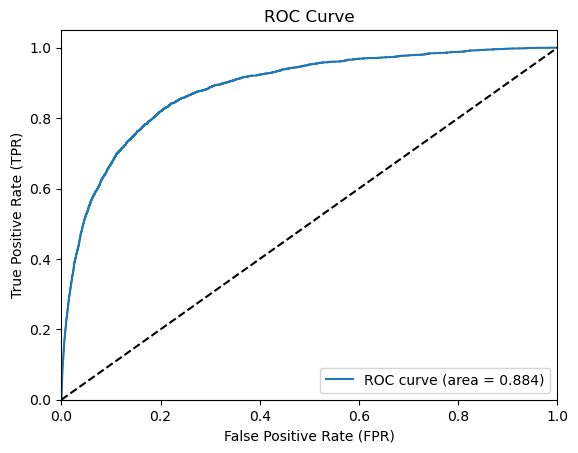

In [30]:
y_pred = model.predict_proba(Xte)[:, 1]  # probabilities for class 1
fpr, tpr, _ = metrics.roc_curve(yte, y_pred)
roc_auc = metrics.auc(fpr, tpr)

# ROC
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # bisector
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [31]:
y_pred_f1 = model.predict(Xte)

f1 = metrics.f1_score(yte, y_pred_f1, average=None)
precision = metrics.precision_score(yte, y_pred_f1, average=None)
recall = metrics.recall_score(yte, y_pred_f1, average=None)
# overall precision
precision_avg = metrics.precision_score(yte, y_pred_f1, average='weighted')
recall_avg = metrics.recall_score(yte, y_pred_f1, average='weighted')
f1_avg = metrics.f1_score(yte, y_pred_f1, average='weighted')
acc = metrics.accuracy_score(yte, y_pred_f1)

print(f'''
Class wise metrics:
{f1=}
{precision=}
{recall=}

Overall metrics
{f1_avg=}
{precision_avg=}
{recall_avg=}
''')


Class wise metrics:
f1=array([0.99268629, 0.07581454])
precision=array([0.98646451, 0.37345679])
recall=array([0.99898705, 0.04218968])

Overall metrics
f1_avg=0.9797499858846571
precision_avg=0.9778154805029988
recall_avg=0.9854874257152977



[[0.99898705 0.00101295]
 [0.95781032 0.04218968]]


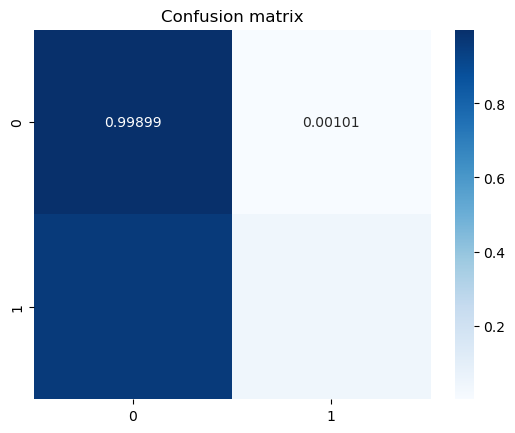

In [32]:
import seaborn as sns

cm = metrics.confusion_matrix(yte, y_pred_f1)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

print(cm_norm)

plt.title("Confusion matrix")
sns.heatmap(cm_norm, annot=True, fmt=".5f", cmap="Blues")
plt.show()

## Oversampled dataset

In [33]:
best_score = None

choice = input("Do you want to execute this cell? (yes/no): ")
if choice.lower() == "yes":
    print("Executing cross validation...")
    best_params, best_score = CV(
        Xtr_oversampled, ytr_oversampled, Xval_oversampled, yval_oversampled, **param_grid)
    with open(f'{BEST_PARAMS_PATH}/../oversampling/LGBM/best_params_gpu.json', 'w') as f:
        json.dump(best_params, f)
else:
    print("Loading data locally...")
    with open(f'{BEST_PARAMS_PATH}/../oversampling/LGBM/best_params_gpu.json', 'r') as f:
        best_params = json.load(f)

print(f"Best params:")
print(json.dumps(best_params, indent=2))
if best_score:
    print(f"Best score: {best_score}")

Loading data locally...
Best params:
{
  "colsample_bytree": 1.0,
  "learning_rate": 0.2,
  "max_depth": 16,
  "min_child_samples": 30,
  "n_estimators": 300,
  "num_leaves": 50,
  "subsample": 0.6
}


In [34]:
model = lgb.LGBMClassifier(**best_params, **model_settings, random_state=1)
model.fit(Xtr_oversampled, ytr_oversampled,
          categorical_feature=categorical_idxs)

LGBMClassifier(bagging_fraction=0.8, bagging_freq=5, device='cpu',
               feature_fraction=0.9, learning_rate=0.2, max_depth=16,
               metric='roc_auc', min_child_samples=30, n_estimators=300,
               num_leaves=50, objective='binary', random_state=1, subsample=0.6,
               verbose=-1)

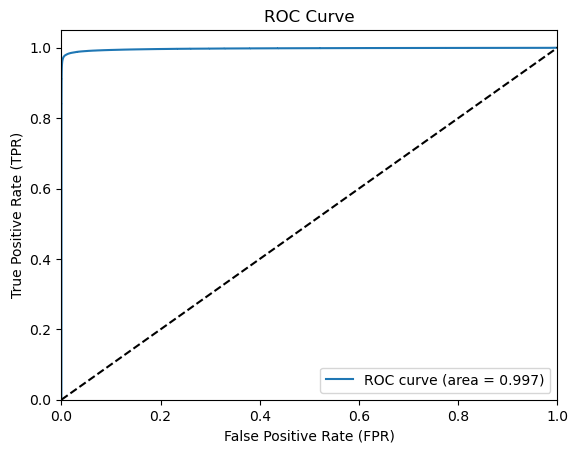

In [35]:
y_pred = model.predict_proba(Xte_oversampled)[
    :, 1]  # probabilities for class 1
fpr, tpr, _ = metrics.roc_curve(yte_oversampled, y_pred)
roc_auc = metrics.auc(fpr, tpr)

# ROC
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # bisector
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [36]:
y_pred_f1 = model.predict(Xte_oversampled)

f1 = metrics.f1_score(yte_oversampled, y_pred_f1, average=None)
precision = metrics.precision_score(yte_oversampled, y_pred_f1, average=None)
recall = metrics.recall_score(yte_oversampled, y_pred_f1, average=None)
# overall precision
precision_avg = metrics.precision_score(
    yte_oversampled, y_pred_f1, average='weighted')
recall_avg = metrics.recall_score(
    yte_oversampled, y_pred_f1, average='weighted')
f1_avg = metrics.f1_score(yte_oversampled, y_pred_f1, average='weighted')
acc = metrics.accuracy_score(yte_oversampled, y_pred_f1)

print(f'''
Class wise metrics:
{f1=}
{precision=}
{recall=}

Overall metrics
{f1_avg=}
{precision_avg=}
{recall_avg=}
''')


Class wise metrics:
f1=array([0.98022218, 0.98406452])
precision=array([0.96455449, 0.99711449])
recall=array([0.99640726, 0.97135172])

Overall metrics
f1_avg=0.9823778911369749
precision_avg=0.9828220265200999
recall_avg=0.9823500421645183



[[0.99640726 0.00359274]
 [0.02864828 0.97135172]]


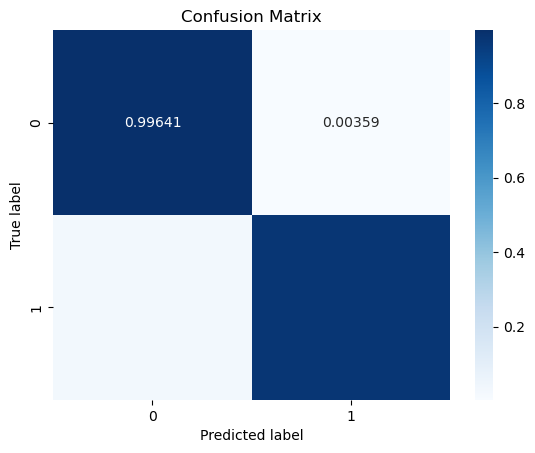

In [37]:
cm = metrics.confusion_matrix(yte_oversampled, y_pred_f1)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

print(cm_norm)
plt.title("Confusion matrix")
sns.heatmap(cm_norm, annot=True, fmt=".5f", cmap="Blues")
plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

In [ ]:
# TODO: why does light gbm performs that much better?
# TODO: investigate how the ROC curve is built
# TODO: why the oversampled case is that much better?

'''
to understand if data is enough, try sampling different points and evaluate
the standard deviation of the model performance. If it's low, than i have enough data,
otherwise the set is too small
'''